# Agrupamiento (Clustering) mediante Optimización por Enjambre de Partículas (PSO)

---

 Conjunto de Datos

Se utiliza el conjunto de datos **Mall Customer Segmentation** (simulado con parámetros reales), comúnmente utilizado para segmentación de clientes:

- **Variables:** Edad, Ingreso anual (k$), Puntuación de gasto (1-100)
- **Muestras:** 200 clientes
- **Tarea:** Identificar segmentos naturales de clientes sin información de etiquetas


In [4]:
# ============================================================
# IMPORTACIÓN DE BIBLIOTECAS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

np.random.seed(42)
print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


In [5]:
# ============================================================
# GENERACIÓN DEL DATASET: SEGMENTACIÓN DE CLIENTES
# ============================================================
# Los clústeres naturales corresponden a 5 segmentos de clientes:
# 1. Jóvenes con bajo ingreso y alto gasto
# 2. Adultos con alto ingreso y alto gasto (clientes premium)
# 3. Adultos con alto ingreso y bajo gasto (ahorradores)
# 4. Personas de mediana edad con ingreso y gasto moderados
# 5. Adultos mayores con bajo ingreso y bajo gasto

np.random.seed(42)
n_per_cluster = 40

clusters_params = [
    # [edad_media, edad_std, ingreso_media, ingreso_std, gasto_media, gasto_std]
    [25, 5,  25, 8,  70, 12],   # Segmento 1: jóvenes, bajo ingreso, alto gasto
    [35, 7,  85, 15, 82, 10],   # Segmento 2: premium
    [45, 8,  88, 12, 18, 10],   # Segmento 3: ahorradores con alto ingreso
    [42, 10, 55, 12, 50, 15],   # Segmento 4: moderados
    [58, 10, 28, 10, 22, 10],   # Segmento 5: mayores, bajo ingreso y gasto
]

data_list = []
true_labels_list = []

for k, (am, as_, im, is_, gm, gs) in enumerate(clusters_params):
    ages    = np.random.normal(am, as_, n_per_cluster).clip(18, 80)
    incomes = np.random.normal(im, is_, n_per_cluster).clip(10, 150)
    scores  = np.random.normal(gm, gs,  n_per_cluster).clip(1, 100)
    segment = np.column_stack([ages, incomes, scores])
    data_list.append(segment)
    true_labels_list.extend([k] * n_per_cluster)

X_raw = np.vstack(data_list)
true_labels = np.array(true_labels_list)

df_customers = pd.DataFrame(X_raw, columns=['Edad', 'Ingreso_anual_k', 'Puntuacion_gasto'])
df_customers['Segmento_real'] = true_labels

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Dataset: Segmentación de Clientes")
print(f"Muestras totales: {X_raw.shape[0]}")
print(f"Características: {X_raw.shape[1]} (Edad, Ingreso Anual, Puntuación de Gasto)")
print(f"Clusters naturales (ground truth): 5")
print("\nEstadísticas descriptivas:")
df_customers[['Edad', 'Ingreso_anual_k', 'Puntuacion_gasto']].describe().round(2)

Dataset: Segmentación de Clientes
Muestras totales: 200
Características: 3 (Edad, Ingreso Anual, Puntuación de Gasto)
Clusters naturales (ground truth): 5

Estadísticas descriptivas:


,Edad,Ingreso_anual_k,Puntuacion_gasto
count,200.00,200.00,200.00
mean,40.70,56.53,48.32
std,13.52,30.27,28.15
min,18.00,10.00,1.00
25%,29.04,27.89,21.90
50%,40.34,55.85,47.64
75%,49.85,85.42,73.24
max,77.09,125.80,100.00


## 3. Visualización del Dataset

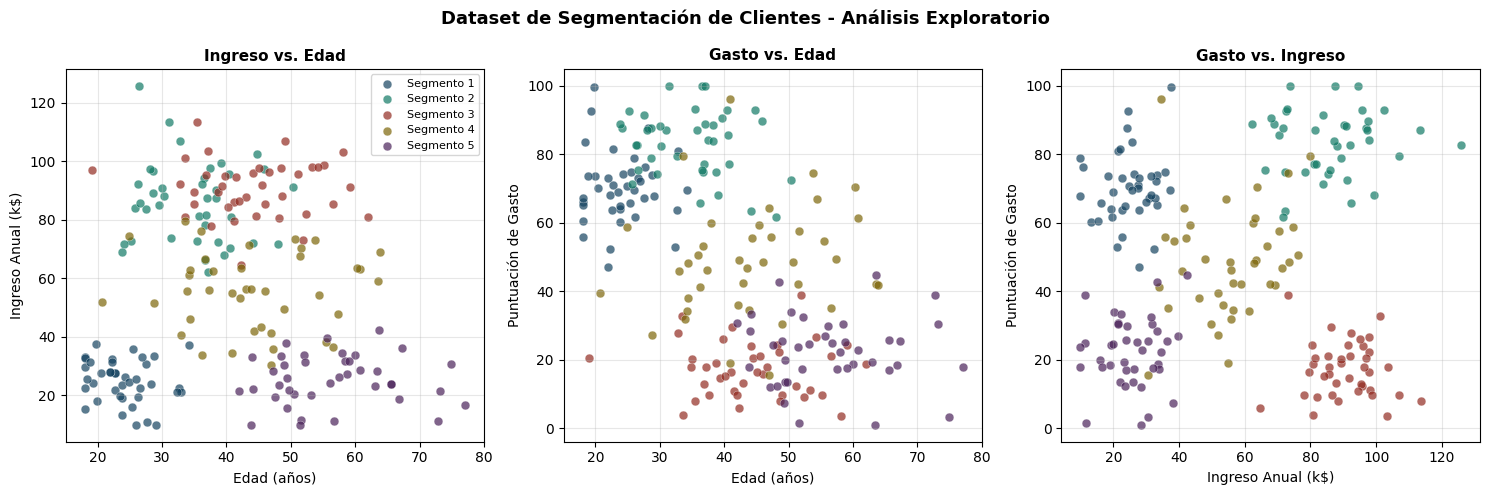

In [6]:
# ============================================================
# EXPLORACIÓN VISUAL DEL DATASET
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Dataset de Segmentación de Clientes - Análisis Exploratorio',
             fontsize=13, fontweight='bold')

features = ['Edad', 'Ingreso_anual_k', 'Puntuacion_gasto']
pairs = [(0, 1), (0, 2), (1, 2)]
xlabels = ['Edad (años)', 'Edad (años)', 'Ingreso Anual (k$)']
ylabels = ['Ingreso Anual (k$)', 'Puntuación de Gasto', 'Puntuación de Gasto']

colors = ['#154360', '#117a65', '#922b21', '#7d6608', '#4a235a']

for ax, (i, j), xl, yl in zip(axes, pairs, xlabels, ylabels):
    for seg in range(5):
        mask = true_labels == seg
        ax.scatter(X_raw[mask, i], X_raw[mask, j],
                  color=colors[seg], alpha=0.7, s=40,
                  label=f'Segmento {seg+1}', edgecolors='white', linewidths=0.3)
    ax.set_xlabel(xl, fontsize=10)
    ax.set_ylabel(yl, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_title('Ingreso vs. Edad', fontsize=11, fontweight='bold')
axes[1].set_title('Gasto vs. Edad', fontsize=11, fontweight='bold')
axes[2].set_title('Gasto vs. Ingreso', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('clustering_data.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Implementación de PSO-Clustering

In [7]:
# ============================================================
# FUNCIÓN DE APTITUD: WITHIN-CLUSTER SUM OF SQUARES (WCSS)
# ============================================================
def assign_clusters(X, centroids):
    """
    Asigna cada punto de datos al centroide más cercano.

    Parámetros:
    -----------
    X : np.ndarray de forma (n_samples, n_features)
    centroids : np.ndarray de forma (k, n_features)

    Retorna:
    --------
    labels : np.ndarray de forma (n_samples,) - Índice del centroide más cercano.
    """
    dists = np.array([np.sum((X - c)**2, axis=1) for c in centroids])  # (k, n)
    return np.argmin(dists, axis=0)


def wcss_fitness(particle, X, k, n_features):
    """
    Calcula la función de aptitud WCSS (Within-Cluster Sum of Squares).

    Parámetros:
    -----------
    particle : np.ndarray de forma (k * n_features,)
        Vector plano que codifica las posiciones de los k centroides.
    X : np.ndarray - Datos de entrada.
    k : int - Número de clusters.
    n_features : int - Número de características.

    Retorna:
    --------
    float : Negativo del WCSS (PSO maximiza, se minimiza el WCSS).
    """
    centroids = particle.reshape(k, n_features)
    labels = assign_clusters(X, centroids)

    wcss = 0.0
    for j in range(k):
        members = X[labels == j]
        if len(members) > 0:
            wcss += np.sum((members - centroids[j])**2)

    return -wcss / len(X)  # Normalizamos por número de puntos


print("Funcion de aptitud WCSS definida correctamente.")
print("Objetivo: MINIMIZAR WCSS (maximizando su negativo con PSO)")

Funcion de aptitud WCSS definida correctamente.
Objetivo: MINIMIZAR WCSS (maximizando su negativo con PSO)


In [8]:
# ============================================================
# CLASE PSO-CLUSTERING
# ============================================================
class PSOClustering:
    """
    Algoritmo PSO para clustering no supervisado.

    Cada partícula codifica k centroides como un vector continuo
    de dimensión k * n_features. La función de aptitud es el WCSS normalizado.

    Parámetros:
    -----------
    k : int
        Número de clusters.
    n_particles : int
        Número de partículas.
    max_iter : int
        Número máximo de iteraciones.
    w, c1, c2 : float
        Coeficientes de inercia, cognitivo y social.
    """

    def __init__(self, k=5, n_particles=30, max_iter=100, w=0.7, c1=1.5, c2=1.5):
        self.k           = k
        self.n_particles = n_particles
        self.max_iter    = max_iter
        self.w           = w
        self.c1          = c1
        self.c2          = c2

        self.fitness_history = []
        self.best_labels     = None
        self.best_centroids  = None
        self.g_best_val      = -np.inf

    def fit(self, X):
        """
        Ajusta el modelo PSO-Clustering sobre los datos X.

        Parámetros:
        -----------
        X : np.ndarray de forma (n_samples, n_features)

        Retorna:
        --------
        self : instancia ajustada.
        """
        n_samples, n_features = X.shape
        n_dim = self.k * n_features

        # Inicialización: seleccionar puntos reales como centroides iniciales (K-Means++)
        positions = np.zeros((self.n_particles, n_dim))
        for p in range(self.n_particles):
            # Seleccionar k puntos aleatorios del dataset como centroides iniciales
            indices = np.random.choice(n_samples, self.k, replace=False)
            positions[p] = X[indices].flatten()

        # Inicialización de velocidades
        data_range = X.max(axis=0) - X.min(axis=0)
        v_max = np.tile(data_range * 0.1, self.k)
        velocities = np.random.uniform(-v_max, v_max, (self.n_particles, n_dim))

        p_best_pos = positions.copy()
        p_best_val = np.full(self.n_particles, -np.inf)
        g_best_pos = None

        print("=" * 60)
        print("INICIO DE PSO-CLUSTERING")
        print(f"Número de clusters (k): {self.k}")
        print(f"Partículas: {self.n_particles} | Iteraciones: {self.max_iter}")
        print(f"Dimensión de partícula: {n_dim} ({self.k} centroides x {n_features} características)")
        print("=" * 60)

        # Evaluación inicial
        for i in range(self.n_particles):
            val = wcss_fitness(positions[i], X, self.k, n_features)
            p_best_val[i] = val
            if val > self.g_best_val:
                self.g_best_val = val
                g_best_pos = positions[i].copy()

        # Ciclo principal
        for iteration in range(self.max_iter):
            w_curr = self.w - (self.w - 0.4) * (iteration / self.max_iter)

            r1 = np.random.rand(self.n_particles, n_dim)
            r2 = np.random.rand(self.n_particles, n_dim)

            velocities = (w_curr * velocities
                         + self.c1 * r1 * (p_best_pos - positions)
                         + self.c2 * r2 * (g_best_pos - positions))

            positions = positions + velocities

            for i in range(self.n_particles):
                val = wcss_fitness(positions[i], X, self.k, n_features)
                if val > p_best_val[i]:
                    p_best_val[i] = val
                    p_best_pos[i] = positions[i].copy()
                if val > self.g_best_val:
                    self.g_best_val = val
                    g_best_pos = positions[i].copy()

            self.fitness_history.append(-self.g_best_val)  # Guardar WCSS positivo

            if (iteration + 1) % 20 == 0 or iteration == 0:
                print(f"Iteración {iteration+1:4d}/{self.max_iter} | WCSS: {-self.g_best_val:.4f}")

        # Extraer resultado final
        self.best_centroids = g_best_pos.reshape(self.k, n_features)
        self.best_labels    = assign_clusters(X, self.best_centroids)

        print("\n" + "=" * 60)
        print("CLUSTERING FINALIZADO")
        print(f"WCSS final: {-self.g_best_val:.4f}")
        print(f"Distribución de clusters:")
        for j in range(self.k):
            count = np.sum(self.best_labels == j)
            print(f"  Cluster {j+1}: {count} puntos")
        print("=" * 60)

        return self


print("Clase PSOClustering definida correctamente.")

Clase PSOClustering definida correctamente.


## 5. Ejecución del Clustering

In [9]:
# ============================================================
# EJECUCIÓN DE PSO-CLUSTERING
# ============================================================
K_CLUSTERS = 5

pso_clust = PSOClustering(
    k=K_CLUSTERS,
    n_particles=25,
    max_iter=80,
    w=0.729,
    c1=1.494,
    c2=1.494
)

pso_clust.fit(X_scaled)

INICIO DE PSO-CLUSTERING
Número de clusters (k): 5
Partículas: 25 | Iteraciones: 80
Dimensión de partícula: 15 (5 centroides x 3 características)
Iteración    1/80 | WCSS: 0.8705
Iteración   20/80 | WCSS: 0.6740
Iteración   40/80 | WCSS: 0.5845
Iteración   60/80 | WCSS: 0.5802
Iteración   80/80 | WCSS: 0.5795

CLUSTERING FINALIZADO
WCSS final: 0.5795
Distribución de clusters:
  Cluster 1: 41 puntos
  Cluster 2: 40 puntos
  Cluster 3: 42 puntos
  Cluster 4: 39 puntos
  Cluster 5: 38 puntos


## 6. Evaluación y Comparación con K-Means

In [10]:
# ============================================================
# EVALUACIÓN CON MÉTRICAS DE CLUSTERING
# ============================================================
# K-Means de referencia
kmeans = KMeans(n_clusters=K_CLUSTERS, init='k-means++', n_init=20, random_state=42)
kmeans.fit(X_scaled)
km_labels = kmeans.labels_

pso_labels = pso_clust.best_labels

# Métricas de validación interna
sil_pso = silhouette_score(X_scaled, pso_labels)
sil_km  = silhouette_score(X_scaled, km_labels)

db_pso  = davies_bouldin_score(X_scaled, pso_labels)
db_km   = davies_bouldin_score(X_scaled, km_labels)

ch_pso  = calinski_harabasz_score(X_scaled, pso_labels)
ch_km   = calinski_harabasz_score(X_scaled, km_labels)

wcss_pso = sum(np.sum((X_scaled[pso_labels==j] - pso_clust.best_centroids[j])**2)
               for j in range(K_CLUSTERS))
wcss_km  = kmeans.inertia_

print("MÉTRICAS DE EVALUACIÓN DE CLUSTERING")
print("=" * 60)
print(f"{'Métrica':<35} {'PSO':>10} {'K-Means':>10}")
print("-" * 60)
print(f"{'Silhouette Score (mayor=mejor)':<35} {sil_pso:>10.4f} {sil_km:>10.4f}")
print(f"{'Davies-Bouldin Index (menor=mejor)':<35} {db_pso:>10.4f} {db_km:>10.4f}")
print(f"{'Calinski-Harabasz Score (mayor=mejor)':<35} {ch_pso:>10.1f} {ch_km:>10.1f}")
print(f"{'WCSS (menor=mejor)':<35} {wcss_pso:>10.2f} {wcss_km:>10.2f}")
print("-" * 60)

MÉTRICAS DE EVALUACIÓN DE CLUSTERING
Métrica                                    PSO    K-Means
------------------------------------------------------------
Silhouette Score (mayor=mejor)          0.4708     0.4708
Davies-Bouldin Index (menor=mejor)      0.8743     0.8743
Calinski-Harabasz Score (mayor=mejor)      203.7      203.7
WCSS (menor=mejor)                      115.91     115.87
------------------------------------------------------------


## 7. Visualización de Resultados

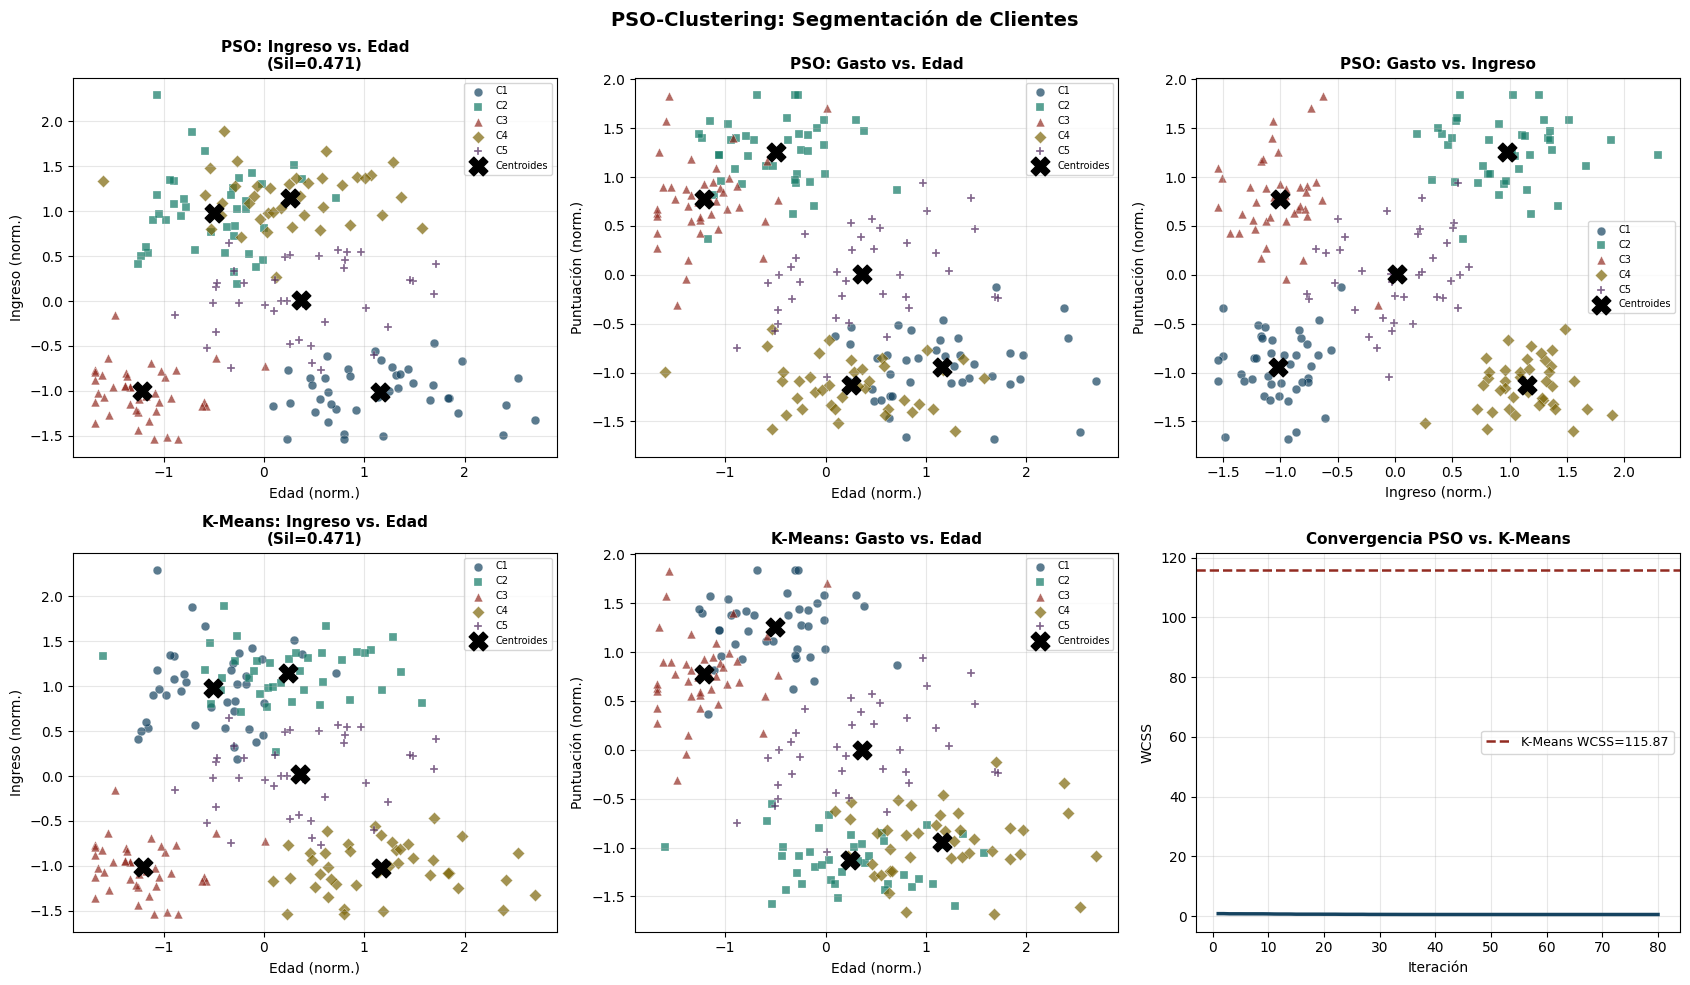

Graficas generadas y guardadas.


In [11]:
# ============================================================
# GRÁFICAS COMPARATIVAS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('PSO-Clustering: Segmentación de Clientes',
             fontsize=14, fontweight='bold')

colors_clust = ['#154360', '#117a65', '#922b21', '#7d6608', '#4a235a']
markers = ['o', 's', '^', 'D', 'P']

# Función auxiliar para graficar clusters
def plot_clusters(ax, X_data, labels, centroids_scaled, title, xlabel, ylabel, fi, fj):
    k = len(np.unique(labels))
    for j in range(k):
        mask = labels == j
        ax.scatter(X_data[mask, fi], X_data[mask, fj],
                  color=colors_clust[j], alpha=0.7, s=40, marker=markers[j],
                  edgecolors='white', linewidths=0.3, label=f'C{j+1}')
    if centroids_scaled is not None:
        ax.scatter(centroids_scaled[:, fi], centroids_scaled[:, fj],
                  c='black', s=180, marker='X', zorder=5, label='Centroides')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

feat_labels = ['Edad (norm.)', 'Ingreso (norm.)', 'Puntuación (norm.)']

# Fila 1: Resultados PSO
plot_clusters(axes[0,0], X_scaled, pso_labels, pso_clust.best_centroids,
              f'PSO: Ingreso vs. Edad\n(Sil={sil_pso:.3f})',
              feat_labels[0], feat_labels[1], 0, 1)
plot_clusters(axes[0,1], X_scaled, pso_labels, pso_clust.best_centroids,
              f'PSO: Gasto vs. Edad',
              feat_labels[0], feat_labels[2], 0, 2)
plot_clusters(axes[0,2], X_scaled, pso_labels, pso_clust.best_centroids,
              f'PSO: Gasto vs. Ingreso',
              feat_labels[1], feat_labels[2], 1, 2)

# Fila 2: Resultados K-Means
plot_clusters(axes[1,0], X_scaled, km_labels, kmeans.cluster_centers_,
              f'K-Means: Ingreso vs. Edad\n(Sil={sil_km:.3f})',
              feat_labels[0], feat_labels[1], 0, 1)
plot_clusters(axes[1,1], X_scaled, km_labels, kmeans.cluster_centers_,
              f'K-Means: Gasto vs. Edad',
              feat_labels[0], feat_labels[2], 0, 2)

# Curva de convergencia
axes[1,2].plot(range(1, len(pso_clust.fitness_history)+1), pso_clust.fitness_history,
               color='#154360', linewidth=2.5)
axes[1,2].axhline(y=wcss_km, color='#922b21', linestyle='--',
                  linewidth=1.8, label=f'K-Means WCSS={wcss_km:.2f}')
axes[1,2].set_xlabel('Iteración', fontsize=10)
axes[1,2].set_ylabel('WCSS', fontsize=10)
axes[1,2].set_title('Convergencia PSO vs. K-Means', fontsize=11, fontweight='bold')
axes[1,2].legend(fontsize=9)
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pso_clustering_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graficas generadas y guardadas.")

In [12]:
# ============================================================
# PERFIL DE SEGMENTOS IDENTIFICADOS
# ============================================================
df_results = pd.DataFrame(X_raw, columns=['Edad', 'Ingreso_k', 'Punt_Gasto'])
df_results['Cluster_PSO'] = pso_labels

print("PERFIL DE SEGMENTOS DE CLIENTES (PSO-Clustering)")
print("=" * 65)
profile = df_results.groupby('Cluster_PSO').agg(
    N=("Edad", "count"),
    Edad_Media=("Edad", "mean"),
    Ingreso_Medio=("Ingreso_k", "mean"),
    Gasto_Medio=("Punt_Gasto", "mean")
).round(1)

print(profile.to_string())
print()
print("Interpretación de segmentos:")
print("-" * 65)
for idx, row in profile.iterrows():
    if row['Gasto_Medio'] > 60:
        tipo = "Alta propensión al gasto"
    elif row['Ingreso_Medio'] > 70 and row['Gasto_Medio'] < 35:
        tipo = "Alto ingreso, bajo gasto (ahorradores)"
    elif row['Edad_Media'] > 50:
        tipo = "Adultos mayores, consumo conservador"
    elif row['Ingreso_Medio'] > 60:
        tipo = "Ingreso y gasto moderados"
    else:
        tipo = "Bajo ingreso, consumo conservador"
    print(f"  Cluster {idx}: {tipo} (n={int(row['N'])})")

PERFIL DE SEGMENTOS DE CLIENTES (PSO-Clustering)
              N  Edad_Media  Ingreso_Medio  Gasto_Medio
Cluster_PSO                                            
0            41        56.4           25.7         21.9
1            40        33.9           86.3         83.5
2            42        24.4           25.8         70.0
3            39        43.9           91.1         16.6
4            38        45.6           57.1         48.3

Interpretación de segmentos:
-----------------------------------------------------------------
  Cluster 0: Adultos mayores, consumo conservador (n=41)
  Cluster 1: Alta propensión al gasto (n=40)
  Cluster 2: Alta propensión al gasto (n=42)
  Cluster 3: Alto ingreso, bajo gasto (ahorradores) (n=39)
  Cluster 4: Bajo ingreso, consumo conservador (n=38)
